# 01 - Analyse exploratoire des donnees (EDA)

## Contexte

Ce notebook explore le dataset **Kaggle Leaf Classification**, qui contient
~990 echantillons repartis en **99 especes** de feuilles. Chaque echantillon
est decrit par 192 variables numeriques pre-extraites :

- 64 variables **margin** (contour de la feuille)
- 64 variables **shape** (forme geometrique)
- 64 variables **texture** (texture de surface)

L'objectif de cette EDA est de visualiser la structure du dataset avant la
phase de modelisation.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from src.data import charger_donnees

sns.set_theme(style="whitegrid")

## 1. Chargement des donnees

In [2]:
X, y, label_encoder = charger_donnees()
noms_especes = pd.Series(label_encoder.inverse_transform(y), name="species")

print(f"Dimensions de X : {X.shape}")
print(f"Nombre de classes : {noms_especes.nunique()}")
print(f"Nombre d'echantillons par classe (moyenne) : {len(y) / noms_especes.nunique():.1f}")
print(f"\nTypes des colonnes :\n{X.dtypes.value_counts()}")
print(f"\nValeurs manquantes : {X.isnull().sum().sum()}")
X.head()

Dimensions de X : (990, 192)
Nombre de classes : 99
Nombre d'echantillons par classe (moyenne) : 10.0

Types des colonnes :
float64    192
Name: count, dtype: int64

Valeurs manquantes : 0


,margin1,margin2,margin3,margin4,margin5,margin6,margin7,margin8,margin9,margin10,...,texture55,texture56,texture57,texture58,texture59,texture60,texture61,texture62,texture63,texture64
0,0.007812,0.023438,0.023438,0.003906,0.011719,0.009766,0.027344,0.0,0.001953,0.033203,...,0.007812,0.000000,0.002930,0.002930,0.035156,0.0,0.0,0.004883,0.000000,0.025391
1,0.005859,0.000000,0.031250,0.015625,0.025391,0.001953,0.019531,0.0,0.000000,0.007812,...,0.000977,0.000000,0.000000,0.000977,0.023438,0.0,0.0,0.000977,0.039062,0.022461
2,0.005859,0.009766,0.019531,0.007812,0.003906,0.005859,0.068359,0.0,0.000000,0.044922,...,0.154300,0.000000,0.005859,0.000977,0.007812,0.0,0.0,0.000000,0.020508,0.002930
3,0.000000,0.003906,0.023438,0.005859,0.021484,0.019531,0.023438,0.0,0.013672,0.017578,...,0.000000,0.000977,0.000000,0.000000,0.020508,0.0,0.0,0.017578,0.000000,0.047852
4,0.005859,0.003906,0.048828,0.009766,0.013672,0.015625,0.005859,0.0,0.000000,0.005859,...,0.096680,0.000000,0.021484,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.031250


## 2. Distribution des classes

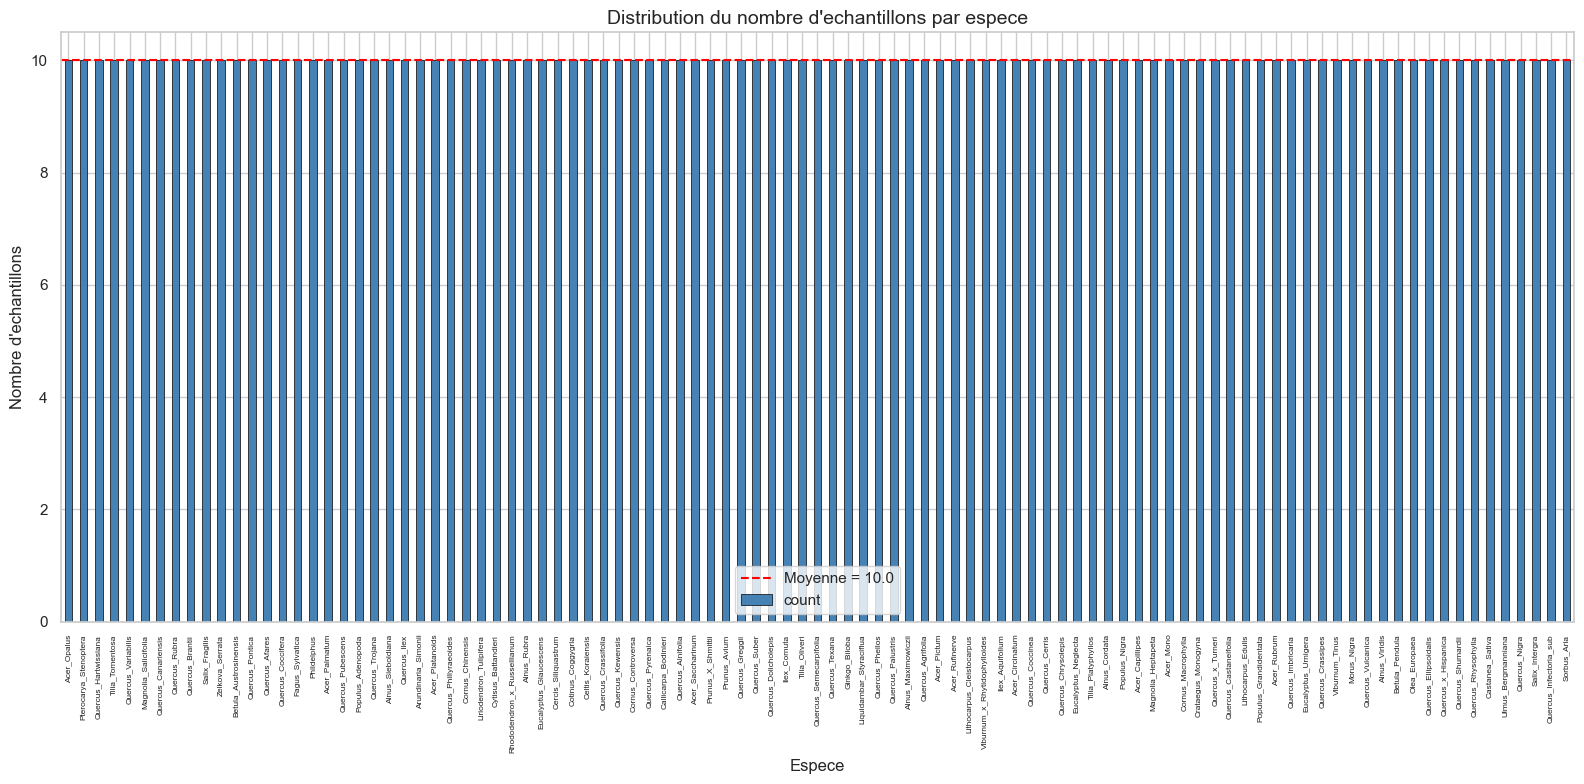

Min echantillons/classe : 10
Max echantillons/classe : 10
Ecart-type : 0.00


In [3]:
comptage = noms_especes.value_counts()

fig, ax = plt.subplots(figsize=(16, 8))
comptage.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black", linewidth=0.5)
ax.set_title("Distribution du nombre d'echantillons par espece", fontsize=14)
ax.set_xlabel("Espece")
ax.set_ylabel("Nombre d'echantillons")
ax.tick_params(axis="x", rotation=90, labelsize=6)
ax.axhline(y=comptage.mean(), color="red", linestyle="--", label=f"Moyenne = {comptage.mean():.1f}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Min echantillons/classe : {comptage.min()}")
print(f"Max echantillons/classe : {comptage.max()}")
print(f"Ecart-type : {comptage.std():.2f}")

**Conclusion.** La distribution est parfaitement equilibree : les 99 especes
possedent chacune exactement **10 echantillons**. Il n'y a donc pas de desequilibre
de classes a compenser dans ce dataset. En revanche, le nombre d'exemples par
classe reste tres faible, ce qui rend la validation croisee stratifiee pertinente
pour obtenir une évaluation stable.

## 3. Boxplots des echelles de variables

On affiche 15 variables aleatoires pour chacune des trois familles de
caracteristiques : `margin`, `shape` et `texture`.

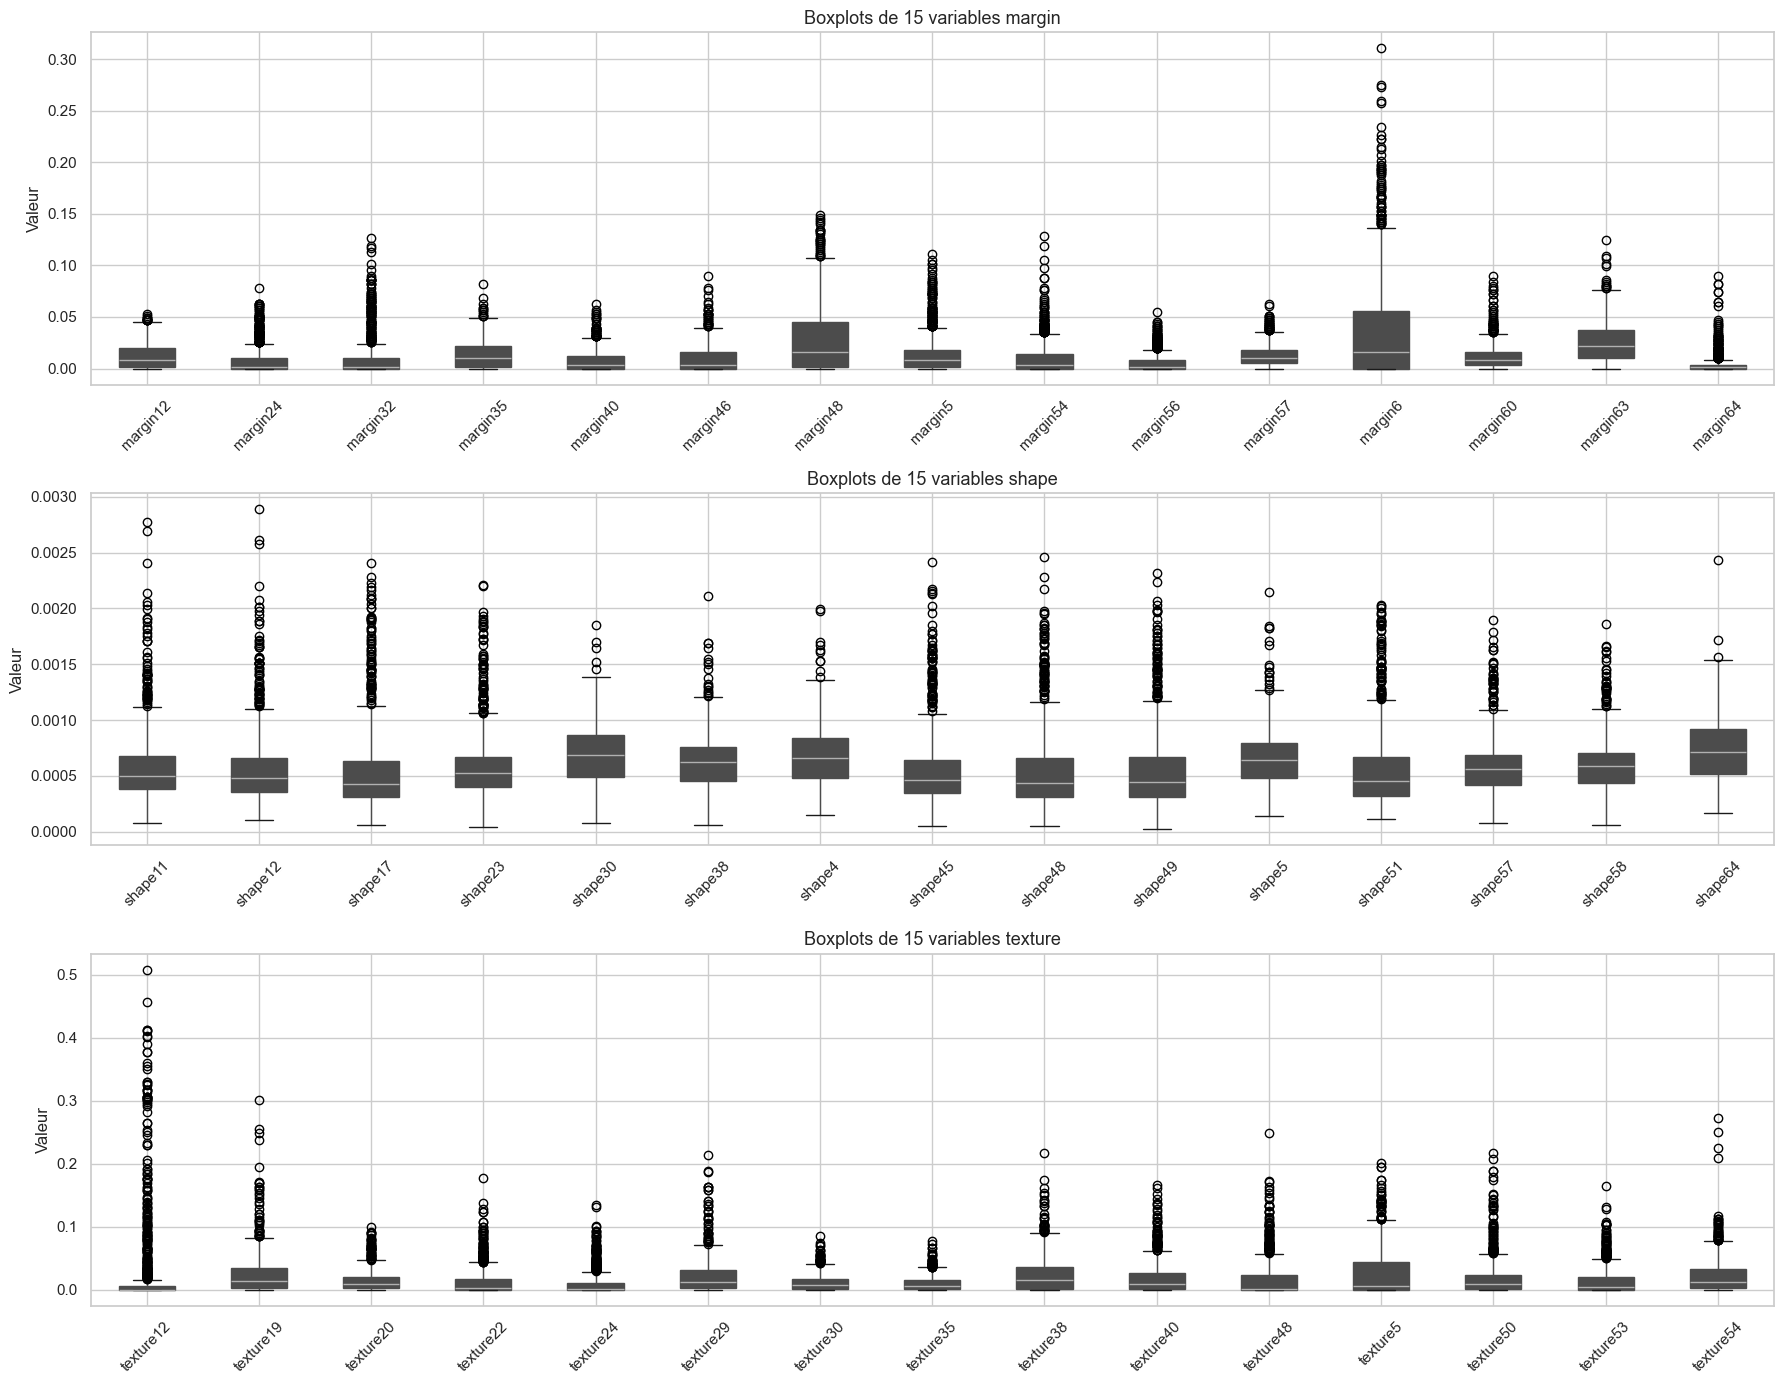

In [4]:
rng = np.random.default_rng(42)

cols_margin = [c for c in X.columns if c.startswith("margin")]
cols_shape = [c for c in X.columns if c.startswith("shape")]
cols_texture = [c for c in X.columns if c.startswith("texture")]

selection_margin = sorted(rng.choice(cols_margin, size=15, replace=False))
selection_shape = sorted(rng.choice(cols_shape, size=15, replace=False))
selection_texture = sorted(rng.choice(cols_texture, size=15, replace=False))

fig, axes = plt.subplots(3, 1, figsize=(18, 14), sharey=False)

X[selection_margin].boxplot(ax=axes[0], vert=True, patch_artist=True)
axes[0].set_title("Boxplots de 15 variables margin", fontsize=13)
axes[0].set_ylabel("Valeur")
axes[0].tick_params(axis="x", rotation=45)

X[selection_shape].boxplot(ax=axes[1], vert=True, patch_artist=True)
axes[1].set_title("Boxplots de 15 variables shape", fontsize=13)
axes[1].set_ylabel("Valeur")
axes[1].tick_params(axis="x", rotation=45)

X[selection_texture].boxplot(ax=axes[2], vert=True, patch_artist=True)
axes[2].set_title("Boxplots de 15 variables texture", fontsize=13)
axes[2].set_ylabel("Valeur")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Conclusion.** Les trois familles de variables n'evoluent pas sur les memes
ordres de grandeur. Les variables `shape` sont tres petites, typiquement de
l'ordre de `1e-4` a `1e-3`, les variables `margin` sont plus etalees, tandis que
les variables `texture` montrent la plus grande dispersion avec plusieurs valeurs
aberrantes elevees. Cette heterogeneite d'echelle justifie clairement une
standardisation pour les modeles sensibles a la magnitude des variables.

## 4. Heatmap de correlation complete

La heatmap suivante represente la matrice de correlation de l'ensemble des
192 variables. Des lignes de separation sont ajoutees apres les blocs
`margin`, `shape` et `texture` pour faire apparaitre les 9 zones de
correlation entre familles de caracteristiques.

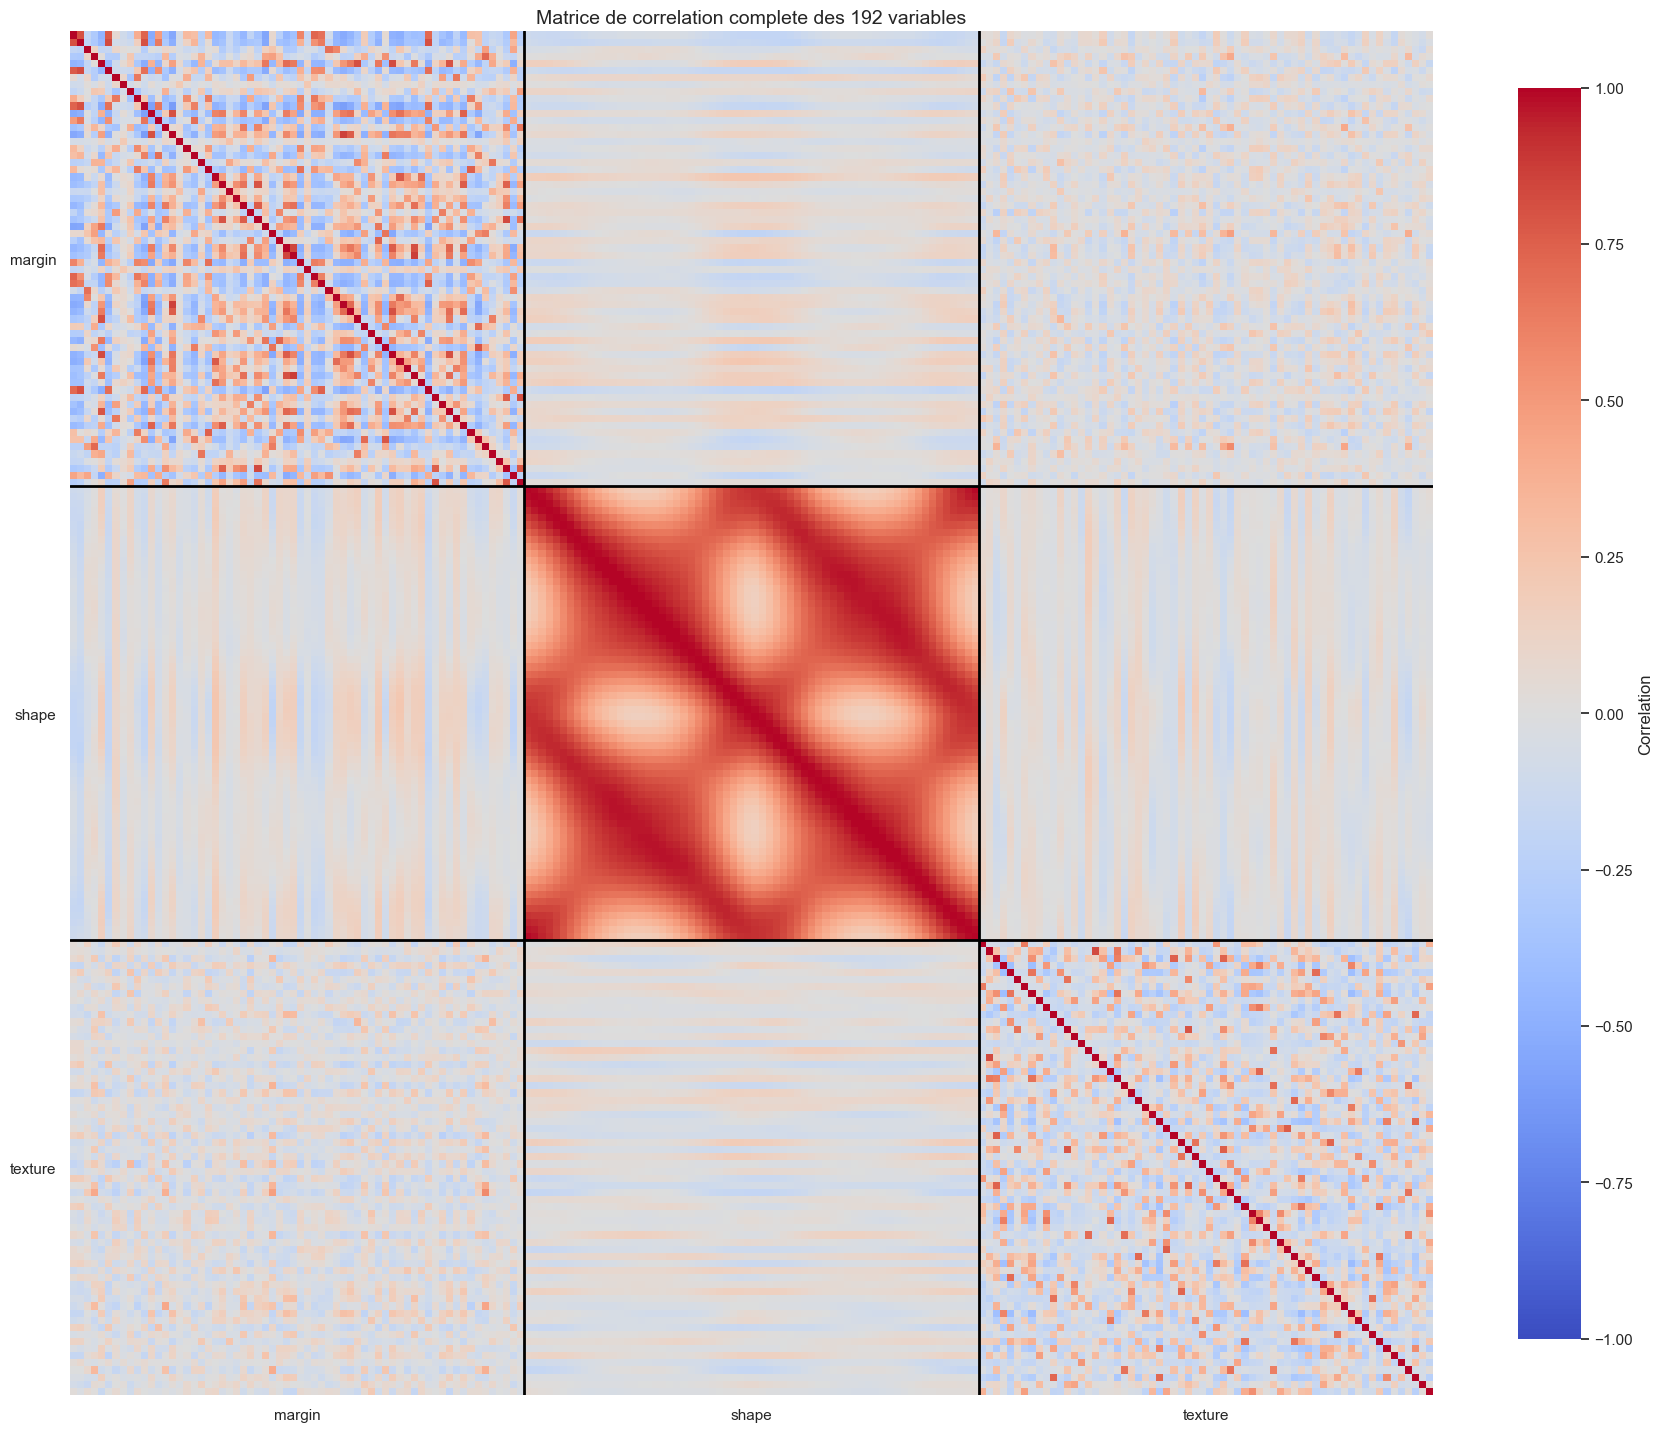

In [5]:
matrice_corr = X.corr()
separations = [64, 128]

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(
    matrice_corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    xticklabels=False,
    yticklabels=False,
    cbar_kws={"shrink": 0.8, "label": "Correlation"},
    ax=ax,
)

for position in separations:
    ax.axhline(position, color="black", linewidth=2)
    ax.axvline(position, color="black", linewidth=2)

centres = [32, 96, 160]
etiquettes = ["margin", "shape", "texture"]
ax.set_xticks(centres)
ax.set_xticklabels(etiquettes, rotation=0)
ax.set_yticks(centres)
ax.set_yticklabels(etiquettes, rotation=0)
ax.set_title("Matrice de correlation complete des 192 variables", fontsize=14)
plt.tight_layout()
plt.show()

**Conclusion.** La structure en 9 blocs met en evidence des comportements tres
differents selon les familles de variables. Le bloc `shape-shape` est le plus
structure et presente de fortes correlations internes, alors que les blocs
`margin-margin` et `texture-texture` paraissent plus heterogenes. Les blocs
inter-familles sont globalement plus faibles, meme si certaines bandes impliquant
`shape` restent visibles. Cela suggere la presence de redondance, en particulier
dans les variables de forme.

## 5. Variance cumulative de la PCA

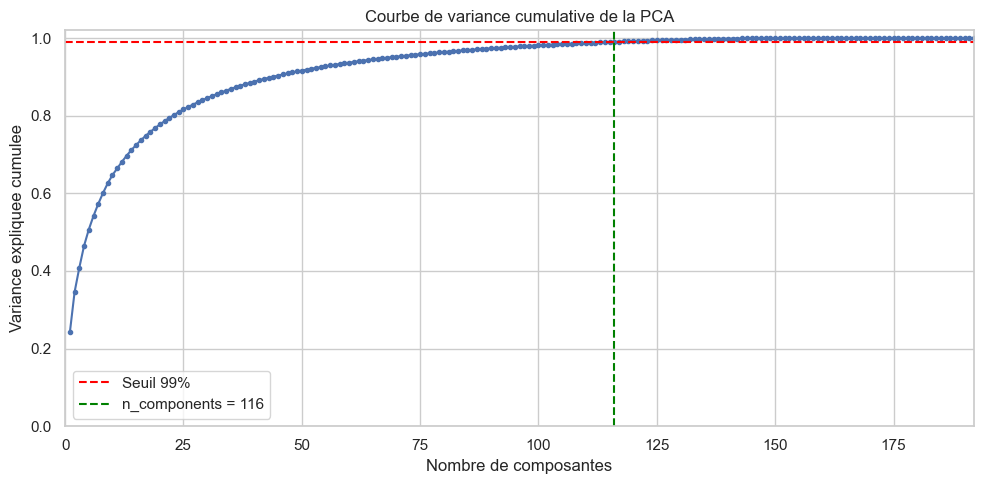

Nombre de composantes pour 99% de variance : 116 (sur 192 originales)


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_complet = PCA()
pca_complet.fit(X_scaled)

variance_cumul = np.cumsum(pca_complet.explained_variance_ratio_)
n_99 = np.argmax(variance_cumul >= 0.99) + 1

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(variance_cumul) + 1), variance_cumul, "b-o", markersize=3)
ax.axhline(y=0.99, color="red", linestyle="--", label="Seuil 99%")
ax.axvline(x=n_99, color="green", linestyle="--", label=f"n_components = {n_99}")
ax.set_xlabel("Nombre de composantes")
ax.set_ylabel("Variance expliquee cumulee")
ax.set_title("Courbe de variance cumulative de la PCA")
ax.legend()
ax.set_xlim(0, len(variance_cumul))
ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

print(f"Nombre de composantes pour 99% de variance : {n_99} (sur {X.shape[1]} originales)")

**Conclusion.** La conservation de **99 %** de la variance necessite environ
**116 composantes principales** sur les 192 variables d'origine. La reduction de
dimension est donc reelle, mais beaucoup moins agressive qu'une hypothese du type
"une quarantaine de composantes suffisent". Si l'on conserve le choix
`PCA(n_components=0.99)`, il faut bien l'interpreter comme une compression moderee
plutot que comme une reduction tres forte de la dimension.

## 6. Projection t-SNE 2D sur toutes les especes

La projection suivante est calculee sur l'ensemble des echantillons et donc
sur les **99 especes** presentes dans le dataset.

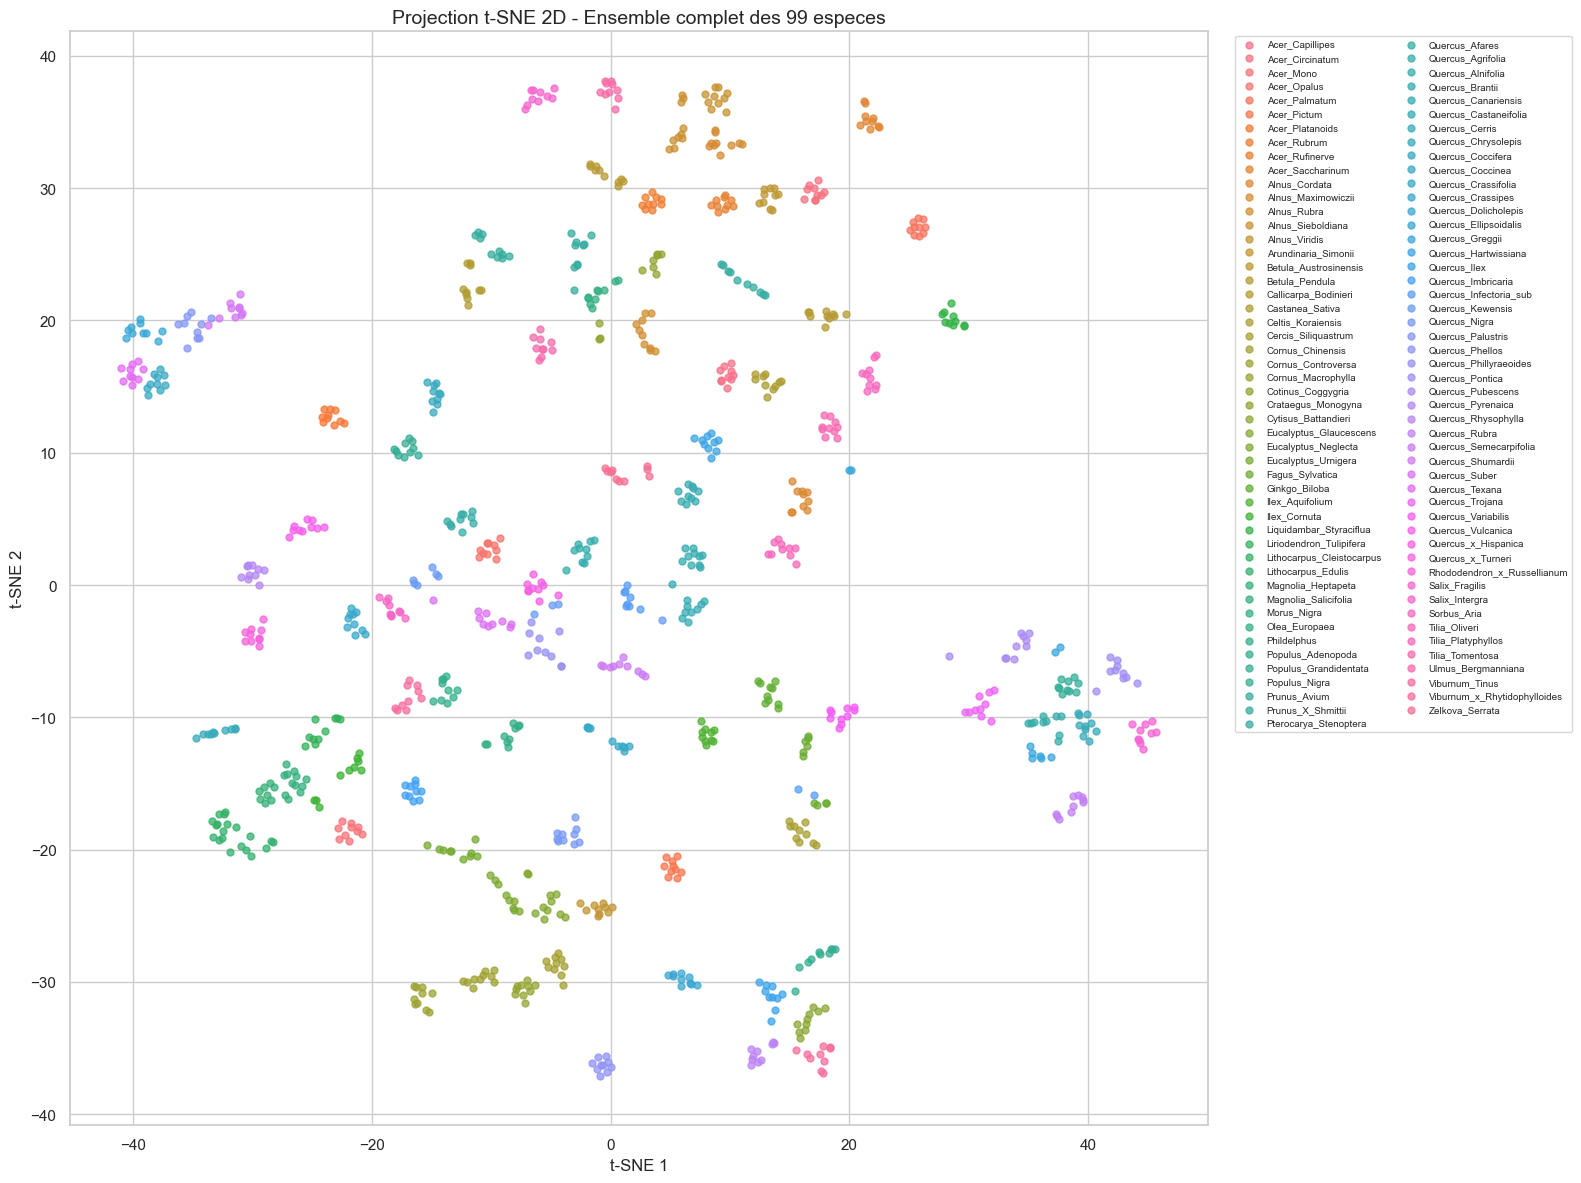

In [7]:
n_classes = len(label_encoder.classes_)

# Reduction PCA prealable pour accelerer t-SNE
n_pca = min(50, X_scaled.shape[1], X_scaled.shape[0])
pca_tsne = PCA(n_components=n_pca, random_state=42)
X_pca = pca_tsne.fit_transform(X_scaled)

tsne = TSNE(
    n_components=2,
    random_state=42,
    init="pca",
    learning_rate="auto",
    perplexity=30,
)
X_tsne = tsne.fit_transform(X_pca)

palette = sns.color_palette("husl", n_classes)
fig, ax = plt.subplots(figsize=(16, 12))

for indice, espece in enumerate(label_encoder.classes_):
    masque_espece = noms_especes == espece
    ax.scatter(
        X_tsne[masque_espece, 0],
        X_tsne[masque_espece, 1],
        s=25,
        alpha=0.75,
        color=palette[indice],
        label=espece,
    )

ax.set_title("Projection t-SNE 2D - Ensemble complet des 99 especes", fontsize=14)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=7,
    ncol=2,
    frameon=True,
)
plt.tight_layout()
plt.show()

**Conclusion.** La projection t-SNE revele de nombreux amas compacts, ce qui
indique que les donnees contiennent une structure discriminante non triviale.
Certaines especes semblent former des groupes relativement bien separes, tandis
que d'autres restent proches dans l'espace projete, ce qui laisse attendre des
confusions entre classes voisines. Comme la figure affiche les 99 especes en meme
temps, elle est informative pour observer la structure globale, mais sa legende est
trop chargee pour une lecture espece par espece.